Traceback (most recent call last):
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 356, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 454, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1595, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1588, in _read


🚀 Start run: LightGBM_classification_best_193113
Fitting 5 folds for each of 81 candidates, totalling 405 fits
[LightGBM] [Info] Number of positive: 62, number of negative: 18
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 98
[LightGBM] [Info] Number of data points in the train set: 80, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.775000 -> initscore=1.236763
[LightGBM] [Info] Start training from score 1.236763
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

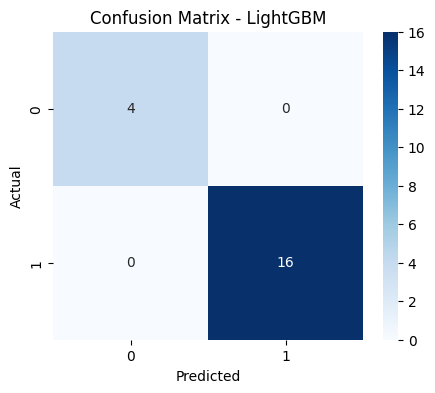

D:\Kaggle\Team_SGU_25_ML_Fundamental\Challenge\2_HousePrices\src\evaluation\Evaluation.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=imp_df, palette="viridis")


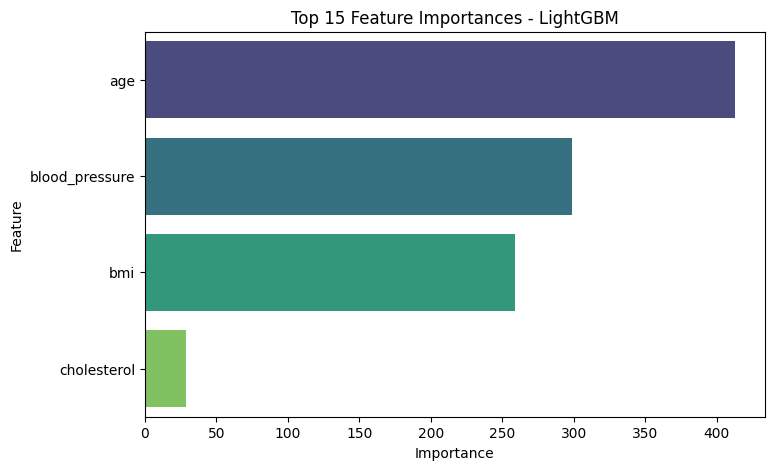

✅ Đã chạy đánh giá đầy đủ cho task: classification.
✅ Model saved to: experiments/models\LightGBM_20251022_193136.pkl
✅ Mô hình đã lưu local: experiments/models\LightGBM_classification_best_193113_20251022_193136_model.pkl


2025/10/22 19:31:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/22 19:31:49 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: data/processed\LightGBM_classification_best_193113_20251022_193150_data.csv


In [3]:
# src/pipeline/run_pipeline.py
import os
import sys
import pandas as pd
import numpy as np

# Cho phép import từ thư mục src
from pipeline.LightGBMPipline import LightGBMPipeline

# ====== Giả lập dữ liệu mẫu ======
np.random.seed(42)
n_samples = 100
df = pd.DataFrame({
    "age": np.random.randint(20, 70, n_samples),
    "bmi": np.random.uniform(18, 32, n_samples).round(1),
    "blood_pressure": np.random.randint(110, 160, n_samples),
    "cholesterol": np.random.randint(160, 240, n_samples),
})

# Sinh nhãn target có quy luật nhẹ
df["disease_risk"] = (
    (df["age"] > 45).astype(int)
    | (df["bmi"] > 27).astype(int)
    | (df["blood_pressure"] > 140).astype(int)
).astype(int)

# ====== Gọi pipeline ======
pipeline = LightGBMPipeline(experiment_name="Health_Experiment")
pipeline.run(
    df=df,
    target_col="disease_risk",
    task="classification",
    model_name="LightGBM",
    backend="mlflow"
)
